### Forward $NVT$ Simulation with Lennard-Jones Potential
In this sample script, we demonstrate how to use JAX-MD to run a forward MD simulation with Lennard-Jones (LJ) potential. Through the script, we will showcase how to use $\psi_6$ order parameter to measure whether a hexagonal latttice has formed during the simulation.

#### 1. Imports and Utility Functions

In [1]:
import numpy as onp

from jax import config
config.update('jax_enable_x64', True)

import jax.numpy as jnp
from jax import random, jit, lax, vmap, jacfwd, remat
from jax.example_libraries import optimizers

import time
import os
from jax_md import space, smap, energy, minimize, quantity, simulate

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style(style='white')

def format_plot(x, y):
  plt.xlabel(x, fontsize=20)
  plt.ylabel(y, fontsize=20)

def finalize_plot(shape=(1, 1)):
  plt.gcf().set_size_inches(
    shape[0] * 1.5 * plt.gcf().get_size_inches()[1],
    shape[1] * 1.5 * plt.gcf().get_size_inches()[1],
  )
  plt.tight_layout()

#### 2. $\psi_k$ Order Parameter

In [2]:
def get_psi_k(displacement_all, k=6, r0=1.1, alpha=100):

  def weight(r, r0=1.1, alpha=100):
    return jnp.where(r<1e-7, 0., 1.0/(1 + jnp.exp(alpha*(r - r0))))

  i_imaginary = complex(0,1)
  def get_ylms(dR_ij):
    epsilon = 0.00001 #avoids nan in derivative
    dR_ij = jnp.where(dR_ij==0.0, epsilon, dR_ij)
    theta = jnp.arctan2(dR_ij[1], dR_ij[0])
    return jnp.exp(i_imaginary*k*theta)

  def calculate_order_param(R):
    v_get_ylms = vmap(vmap(get_ylms))
    ds = displacement_all(R, R)
    r = space.distance(ds)
    w = weight(r)
    psi_k = (jnp.sum(v_get_ylms(ds)*w, axis=0)/(jnp.sum(w, axis=0)+0.00001))
    return psi_k

  def average_order_param(R):
    psi_k = calculate_order_param(R)
    return jnp.abs(jnp.mean(psi_k))

  return average_order_param

#### 3. General 2D Lattice Initialization

In [3]:
def make_2D_lattice_from_index_list(index_list,
                                    a0=jnp.array([jnp.sqrt(2),0.0]),
                                    a1=jnp.array([0.0,jnp.sqrt(2)]),
                                    unitcell=lambda a0, a1: jnp.array([[0.0, 0.0],
                                                                      a0,
                                                                      a1]),
                                    lattice_constant=lambda a0, a1, i, j: jnp.array([[i*a0+j*a1]]),
                                    offset=jnp.array([0.0,0.0])):
  unitcell_particles = unitcell(a0, a1) + offset 
  N = len(unitcell_particles)*index_list.shape[0]
  def get_cell(i,j):
    cell_shift = lattice_constant(a0, a1, i, j)
    return unitcell_particles + cell_shift

  return jnp.reshape(vmap(get_cell, in_axes=(0, 0))(index_list[:,0],index_list[:,1]),(N,2))

def make_2D_lattice(irange, jrange, **kwargs):
  index_list = jnp.array([ [i,j] for i in irange for j in jrange])
  return make_2D_lattice_from_index_list(index_list, **kwargs)

#### 4. Parameters for Simulation

In [26]:
### Global Parameters
M = 20
A0 = 1.5
A1 = 1.5
UNITCELL_SQ = lambda a0, a1: jnp.array([[0.0,0.0]])
LATTICE_CONSTANT_SQ = lambda a0, a1, i, j: jnp.array([[i*a0+j*a1]])
UNITCELL_SQ = jit(UNITCELL_SQ)
LATTICE_CONSTANT_SQ = jit(LATTICE_CONSTANT_SQ)
N = M**2
DIMENSION = 2

RHO = 0.3
BOX_SIZE = (N/RHO)**(1/2)

kT = 0.2
dt = 1e-3
SIGMA = 1.0
R0 = 1.1

key=random.PRNGKey(12)

We will initialize our particles in a dilute square lattice.

In [27]:
R = (make_2D_lattice)(jnp.arange(0,M),jnp.arange(0,M),
                      a0=jnp.array([A0,0.0]),
                      a1=jnp.array([0.0,A1]),
                      unitcell= UNITCELL_SQ,
                      lattice_constant=LATTICE_CONSTANT_SQ,
                      offset=jnp.array([0.01, 0.03]))

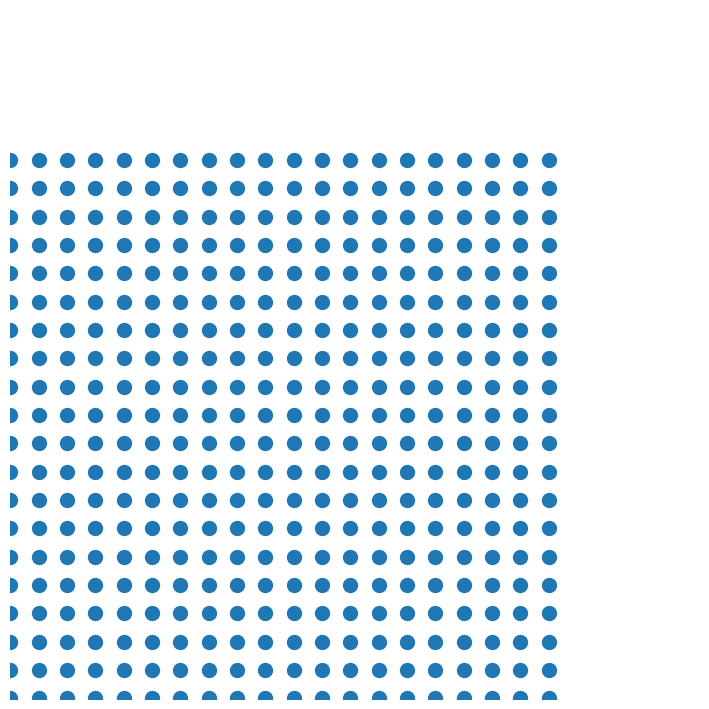

In [28]:
ms = 20
plt.plot(R[:, 0], R[:, 1], 'o', markersize=ms * 0.5)
plt.xlim([0, BOX_SIZE])
plt.ylim([0, BOX_SIZE])
plt.axis('off')
finalize_plot((1, 1))

#### 5. Simulation Setup

In [29]:
displacement, shift = space.periodic(BOX_SIZE)
key, split = random.split(key)

energy_fn = energy.lennard_jones_pair(displacement, sigma = SIGMA)
init, apply = simulate.nvt_nose_hoover(energy_fn, shift, dt, kT = kT)
step = jit(lambda i, state: apply(state))
state = init(key, R)

displacement_all = vmap(vmap(displacement, (0, None), 0), (None, 0), 0)
order_param = get_psi_k(displacement_all, k=6, r0=R0, alpha=100)

PE = [energy_fn(state.position)]
KE = [quantity.kinetic_energy(momentum=state.momentum)]
P = [state.momentum]
T = [quantity.temperature(momentum=state.momentum)]
loss = [order_param(state.position)]
trajectory = [state.position]

N_steps = 2000
inner_steps = 50
print_every = 100
old_time = time.time()
print('Step\tKE\tPE\tTotal Energy\ttime/step')
print('----------------------------------------')

for i in range(N_steps):
  state = lax.fori_loop(0, inner_steps, step, state)

  PE += [energy_fn(state.position)]
  KE += [quantity.kinetic_energy(momentum=state.momentum)]
  P += [state.momentum]
  T += [quantity.temperature(momentum=state.momentum)]
  loss += [order_param(state.position)]
  trajectory += [state.position]

  if i % print_every == 0 and i > 0:
    new_time = time.time()
    print(
      '{}\t{:.2f}\t{:.2f}\t{:.3f}\t{:.2f}'.format(
        i * inner_steps,
        KE[-1],
        PE[-1],
        KE[-1] + PE[-1],
        (new_time - old_time) / print_every / inner_steps,
      )
    )
    old_time = new_time

PE = jnp.array(PE)
KE = jnp.array(KE)
P = jnp.array(P)
T = jnp.array(T)
loss = jnp.array(loss)
trajectory = jnp.array(trajectory)
R = state.position

Step	KE	PE	Total Energy	time/step
----------------------------------------
5000	81.91	-767.78	-685.867	0.00
10000	83.92	-902.82	-818.905	0.00
15000	77.01	-967.79	-890.771	0.00
20000	80.75	-985.25	-904.499	0.00
25000	75.72	-1014.13	-938.411	0.00
30000	81.79	-1033.99	-952.196	0.00
35000	76.80	-1050.13	-973.327	0.00
40000	85.13	-1051.17	-966.033	0.00
45000	80.80	-1060.14	-979.333	0.00
50000	82.17	-1058.16	-975.987	0.00
55000	80.49	-1052.78	-972.299	0.00
60000	83.94	-1059.69	-975.750	0.00
65000	79.84	-1065.76	-985.920	0.00
70000	80.82	-1068.18	-987.364	0.00
75000	73.48	-1070.65	-997.165	0.00
80000	81.69	-1074.77	-993.076	0.00
85000	85.14	-1067.73	-982.589	0.00
90000	82.67	-1071.93	-989.261	0.00
95000	81.02	-1074.07	-993.042	0.00


#### 6. Plot All Measured Quantities

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2526/1343369567.py:17: SyntaxWarning: invalid escape sequence '\p'
  axs[2].set_ylabel('$\psi_6$', fontsize = 18)


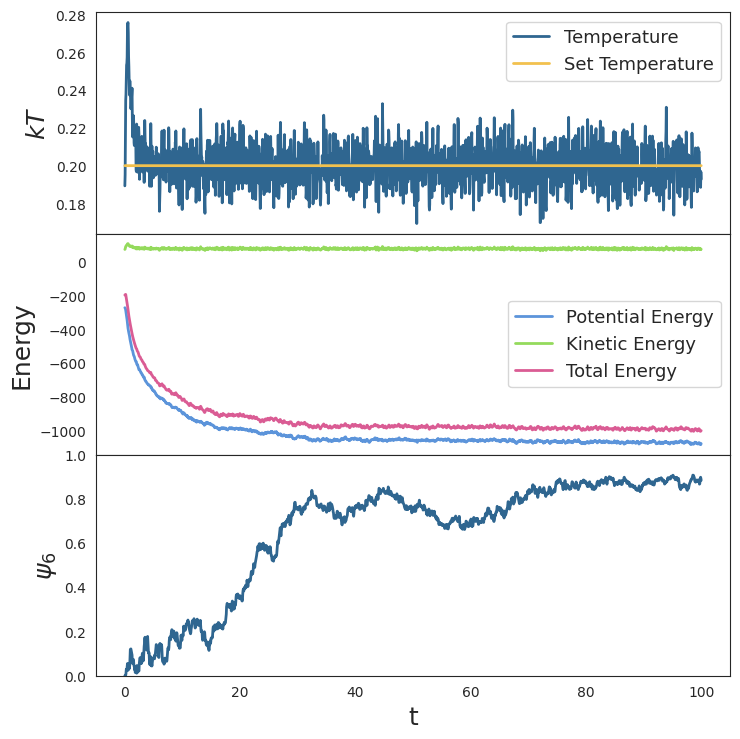

In [83]:
t = onp.arange(0, N_steps+1) * dt * inner_steps

fig = plt.figure(figsize = (8, 5))
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True)

axs[0].plot(t, T, label = 'Temperature', color = '#2f6690', linewidth = 2)
axs[0].plot(t, onp.ones(len(t))*0.2, color = '#f2c14e', label = 'Set Temperature', linewidth = 2)
axs[0].legend(fontsize = 13)
axs[0].set_ylabel('$kT$', fontsize = 18)
axs[1].plot(t, PE, label='Potential Energy', color = '#5c94da', linewidth = 2)
axs[1].plot(t, KE, label='Kinetic Energy', color = '#94da5c', linewidth = 2)
axs[1].plot(t, PE + KE, label='Total Energy', color = '#da5c94', linewidth = 2)
axs[1].legend(fontsize = 13)
axs[1].set_ylabel('Energy', fontsize = 18)
axs[2].plot(t, loss, color = '#2f6690', linewidth = 2)
axs[2].set_ylabel('$\psi_6$', fontsize = 18)
axs[2].set_ylim(0.0, 1.0)
axs[2].set_xlabel('t', fontsize = 18)
finalize_plot()

#### 7. Simulation Snapshots

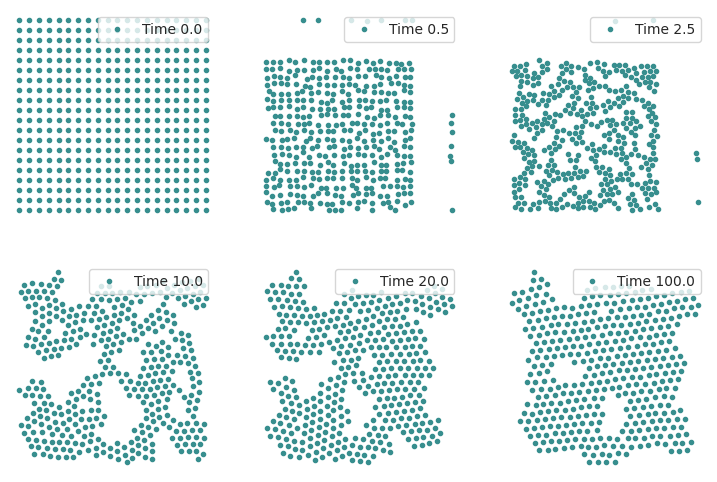

In [63]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(9, 6)
index = [0, 10, 50, 200, 400, 2000]
for i in range(2):
  for j in range(3):
    axs[i, j].plot(trajectory[index[i*3+j], :, 0], trajectory[index[i*3+j], :, 1], 'o', 
                   markersize = ms * 0.15, color = '#378e8e', label = "Time "+str(index[i*3+j]*dt*inner_steps))
    axs[i, j].set_axis_off()
    axs[i, j].legend(loc = 1)